# 04 Transfer Taiwan — 跨國遷移推論

本 notebook 完成以下流程：
1. **Part 1**：載入美國 DeepSolar 資料，以 `voted` 特徵集訓練 Two-Stage 模型（Stage 1: 有無部署分類；Stage 2: 部署強度回歸），並儲存為 `.pkl`。
2. **Part 2**：載入台灣 4 類已整理特徵（氣候、電力、人口、收入），合併為 master table。
3. **Part 3**：建立美國 → 台灣特徵對應表，對齊欄位並以美國 median imputer 補值。
4. **Part 4**：載入儲存的模型，對台灣 368 鄉鎮推論，產出 Stage 1 機率、Stage 2 密度、綜合分數。
5. **Part 5**：快速預覽結果與分布圖。

> **定位**：不預測台灣真實安裝密度，而是利用美國 adoption/deployment pattern 建立台灣各地區的**相對部署傾向與推廣優先度排序**。

In [1]:
import numpy as np
import pandas as pd
import pickle
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import matplotlib.font_manager
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

for font_name in ['Noto Sans CJK TC', 'Microsoft JhengHei', 'SimHei', 'Arial Unicode MS']:
    try:
        matplotlib.font_manager.findfont(font_name, fallback_to_default=False)
        plt.rcParams['font.sans-serif'] = [font_name, 'DejaVu Sans']
        break
    except Exception:
        continue
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# ── Paths ──────────────────────────────────────────────────────────
# Notebook 位於 notebooks/，project root 為上層目錄
ROOT = Path('..')

DATA_PATH      = ROOT / 'deepsolar_tract.csv'
FEATURE_CSV    = ROOT / 'outputs/results/transfer/selected_features_voted.csv'
MODEL_PATH     = ROOT / 'outputs/results/transfer/best_us_twostage_model_voted.pkl'
PRED_PATH      = ROOT / 'outputs/results/transfer/taiwan_predictions.csv'

# Taiwan feature files (已整理好的 features.csv)
TW_CLIMATE = ROOT / 'data/taiwan/氣候資料/taiwan_climate_annual.csv'
TW_POWER   = ROOT / 'data/taiwan/power/taiwan_electricity_features.csv'
TW_POP     = ROOT / 'data/taiwan/人口資料/taiwan_population_features.csv'
TW_INCOME  = ROOT / 'data/taiwan/收入資料/taiwan_income_features.csv'

SEED = 42
np.random.seed(SEED)

## Part 1｜Train & Save US Two-Stage Model

使用 `voted` 特徵集（90 欄）與 notebook `03_model_us_twostage` 的最佳參數，
在美國全資料上訓練後儲存，供後續台灣推論使用。

In [3]:
# 載入美國 DeepSolar 資料
raw_df = pd.read_csv(DATA_PATH, encoding='latin-1')
print(f'US data shape: {raw_df.shape}')

# 載入 voted 特徵清單
feat_df = pd.read_csv(FEATURE_CSV)
feature_names = feat_df['feature'].tolist()
print(f'Voted features requested: {len(feature_names)}')

# 過濾掉 deepsolar_tract.csv 中不存在的欄位
available_features = [f for f in feature_names if f in raw_df.columns]
missing_in_us = [f for f in feature_names if f not in raw_df.columns]
print(f'Available in deepsolar: {len(available_features)}')
if missing_in_us:
    print(f'Missing in deepsolar (will be dropped): {missing_in_us}')

US data shape: (72537, 169)
Voted features requested: 90
Available in deepsolar: 90


In [4]:
# 建立 modeling dataframe
model_df = raw_df[available_features + ['tile_count', 'household_count']].copy()

# 目標變數定義（同 03_model_us_twostage）
y_tile = model_df['tile_count'].fillna(0).values
hh_median = model_df['household_count'].median()
y_households = model_df['household_count'].fillna(hh_median).clip(lower=1).values
y_density = y_tile / y_households * 1000          # solar systems per 1000 households
y_installed = (y_tile > 0).astype(int)            # Stage 1: binary

print(f'Installed rate      : {y_installed.mean():.4f}')
print(f'Density (installed) — mean  : {y_density[y_installed==1].mean():.2f}')
print(f'                      median: {np.median(y_density[y_installed==1]):.2f}')

# Feature matrix
X = model_df[available_features].values
print(f'X shape: {X.shape}')

Installed rate      : 0.7756
Density (installed) — mean  : 216.00
                      median: 5.31
X shape: (72537, 90)


In [5]:
# Median imputation（與 twostage CV pipeline 一致）
imp = SimpleImputer(strategy='median')
X_imp = imp.fit_transform(X)

# ── Stage 1: 有無部署分類 ─────────────────────────────────────────
# 最佳參數來自 03_model_us_twostage RandomForest voted
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    max_features='sqrt',
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1,
    class_weight='balanced',
)
clf.fit(X_imp, y_installed)
print('Stage 1 classifier trained.')

# ── Stage 2: 已部署地區強度回歸（log1p scale）────────────────────
pos_mask = y_installed == 1
reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    max_features=0.3,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1,
)
reg.fit(X_imp[pos_mask], np.log1p(y_density[pos_mask]))
print('Stage 2 regressor trained.')

Stage 1 classifier trained.
Stage 2 regressor trained.


In [6]:
# 儲存 model bundle
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
bundle = {
    'classifier'    : clf,
    'regressor'     : reg,
    'imputer'       : imp,
    'feature_names' : available_features,
    'stage1_target' : 'tile_count > 0',
    'stage2_target' : 'log1p(tile_count / household_count * 1000)',
}
with open(MODEL_PATH, 'wb') as f:
    pickle.dump(bundle, f)
print(f'Model bundle saved to {MODEL_PATH}')

Model bundle saved to ../outputs/results/transfer/best_us_twostage_model_voted.pkl


## Part 2｜Load & Merge Taiwan Features

載入台灣 4 類已整理特徵，以 `TOWNCODE` 為 key 合併。
氣候資料覆蓋全台 368 鄉鎮，以此為基底進行 left merge。

In [7]:
df_climate = pd.read_csv(TW_CLIMATE)
df_power   = pd.read_csv(TW_POWER)
df_pop     = pd.read_csv(TW_POP)
df_income  = pd.read_csv(TW_INCOME)

print(f'Climate: {df_climate.shape}')
print(f'Power  : {df_power.shape}')
print(f'Pop    : {df_pop.shape}')
print(f'Income : {df_income.shape}')

Climate: (368, 17)
Power  : (368, 10)
Pop    : (368, 16)
Income : (368, 8)


In [8]:
# 統一 TOWNCODE 為 int（電力為 float，其餘為 int）
def _clean_towncode(s):
    return s.dropna().astype(int).astype(int)

for df in [df_climate, df_pop, df_income]:
    df['TOWNCODE'] = df['TOWNCODE'].astype(int)
# 電力可能有 NaN，先 drop 再轉
df_power = df_power.dropna(subset=['TOWNCODE']).copy()
df_power['TOWNCODE'] = df_power['TOWNCODE'].astype(int)

# 以氣候為基底（368 鄉鎮全覆蓋），保留所有氣候欄位
# 注意：df_climate 包含 COUNTYNAME/TOWNNAME，後續 merge 時會自動處理重複欄位
tw_master = df_climate.copy()

for df, label, drop_ids in [
    (df_power,  'power',   ['COUNTYNAME','TOWNNAME','郵遞區號','行政區']),
    (df_pop,    'pop',     ['COUNTYNAME','TOWNNAME']),
    (df_income, 'income',  ['COUNTYNAME','TOWNNAME']),
]:
    drop_cols = [c for c in drop_ids if c in df.columns]
    df_merge = df.drop(columns=drop_cols)
    tw_master = tw_master.merge(df_merge, on='TOWNCODE', how='left')
    print(f'After merging {label:6s}: shape={tw_master.shape}, unique TOWNCODE={tw_master["TOWNCODE"].nunique()}')

print(f'\nFinal Taiwan master shape: {tw_master.shape}')

After merging power : shape=(368, 22), unique TOWNCODE=368
After merging pop   : shape=(368, 35), unique TOWNCODE=368
After merging income: shape=(368, 40), unique TOWNCODE=368

Final Taiwan master shape: (368, 40)


In [9]:
# 覆蓋率統計
id_cols = ['TOWNCODE', 'COUNTYNAME', 'TOWNNAME']
feature_cols = [c for c in tw_master.columns if c not in id_cols]

coverage = []
for col in feature_cols:
    non_null = tw_master[col].notna().sum()
    coverage.append({'feature': col, 'non_null': non_null,
                     'coverage': non_null / len(tw_master)})
cov_df = pd.DataFrame(coverage).sort_values('coverage')

print('Lowest coverage features:')
print(cov_df.head(10).to_string(index=False))
print(f'\nFeatures with 100% coverage: {(cov_df.coverage == 1.0).sum()} / {len(cov_df)}')

Lowest coverage features:
                        feature  non_null  coverage
 electricity_consume_commercial       367  0.997283
electricity_consume_residential       367  0.997283
                   centroid_lat       368  1.000000
                  land_area_km2       368  1.000000
                   age_5_9_rate       368  1.000000
                 age_10_14_rate       368  1.000000
                 age_15_17_rate       368  1.000000
                 age_35_44_rate       368  1.000000
             population_density       368  1.000000
                 age_45_54_rate       368  1.000000

Features with 100% coverage: 35 / 37


## Part 3｜Feature Alignment (US → Taiwan)

建立特徵對應表：
- **Direct map**：台灣已有同名列（氣候、電力、人口、收入）
- **Missing**：美國特有欄位（heating_fuel_*, race_*, incentive_*, 交通通勤等）→ 以美國 median 補值

最終輸入矩陣必須與美國模型訓練時的欄位順序完全一致。

In [10]:
us_features = available_features  # from Part 1

# 建立對應：台灣有的直接對應，沒有的標為 None
mapping = {f: (f if f in tw_master.columns else None) for f in us_features}
mapped   = [f for f, v in mapping.items() if v is not None]
unmapped = [f for f, v in mapping.items() if v is None]

print(f'Mapped features  : {len(mapped)}')
print(f'Unmapped features: {len(unmapped)}')
print(f'\nUnmapped (will be imputed by US median):')
for f in unmapped:
    print(f'  - {f}')

Mapped features  : 28
Unmapped features: 62

Unmapped (will be imputed by US median):
  - incentive_count_residential
  - feedin_tariff
  - housing_unit_median_gross_rent
  - rebate
  - incentive_residential_state_level
  - education_college
  - heating_fuel_solar
  - housing_unit_median_value
  - education_bachelor
  - property_tax
  - mortgage_with_rate
  - heating_fuel_gas
  - education_high_school_graduate_rate
  - education_professional_school
  - heating_fuel_solar_rate
  - household_type_family_rate
  - education_doctoral
  - education_bachelor_rate
  - occupancy_owner_rate
  - diversity
  - occupancy_vacant_rate
  - transportation_home_rate
  - health_insurance_public_rate
  - sales_tax
  - health_insurance_none_rate
  - travel_time_average
  - transportation_motorcycle_rate
  - heating_fuel_coal_coke_rate
  - travel_time_less_than_10_rate
  - occupation_finance_rate
  - education_professional_school_rate
  - education_college_rate
  - education_less_than_high_school_rate
  - h

In [11]:
# 對齊欄位順序（與美國模型一致）
X_tw = pd.DataFrame(index=tw_master.index)
for us_f in us_features:
    if mapping[us_f] is not None:
        X_tw[us_f] = tw_master[mapping[us_f]]
    else:
        X_tw[us_f] = np.nan

print(f'Taiwan aligned X shape: {X_tw.shape}')
print(f'Non-null count per feature (top 10):')
print(X_tw.notna().sum().sort_values(ascending=False).head(10))

# 使用已在美國資料上 fit 的 imputer 進行補值
X_tw_imp = imp.transform(X_tw.values)
print('\nImputation done.')

Taiwan aligned X shape: (368, 90)
Non-null count per feature (top 10):
wind_speed                   368
average_household_size       368
population_density           368
age_10_14_rate               368
relative_humidity            368
electricity_consume_total    368
gini_index                   368
age_15_17_rate               368
age_45_54_rate               368
age_35_44_rate               368
dtype: int64

Imputation done.


## Part 4｜Inference on Taiwan

In [12]:
# 載入已儲存的模型（示範 reload；也可直接用記憶體中的 clf / reg）
with open(MODEL_PATH, 'rb') as f:
    bundle_loaded = pickle.load(f)

clf_loaded = bundle_loaded['classifier']
reg_loaded = bundle_loaded['regressor']

# Stage 1: 該地區「像不像美國已部署地區」的機率
stage1_prob = clf_loaded.predict_proba(X_tw_imp)[:, 1]

# Stage 2: 若具備部署條件，預測強度（log scale → 還原）
stage2_log = reg_loaded.predict(X_tw_imp)
stage2_density = np.expm1(stage2_log)

print(f'Stage 1 prob range : [{stage1_prob.min():.4f}, {stage1_prob.max():.4f}]')
print(f'Stage 2 density range: [{stage2_density.min():.2f}, {stage2_density.max():.2f}]')

Stage 1 prob range : [0.7080, 0.8583]
Stage 2 density range: [6.39, 11.25]


In [13]:
# 組合分數
# Stage 1 高 = 像美國已部署地區（adoption tendency 高）
# Stage 2 高 = 若部署，強度可能高（但台灣無真實標籤，不宜解讀為絕對密度）
# Combined: 讓兩階段都高的地區排在前面，但 Stage 1 權重較大（因為我們關心「潛力」）
combined = stage1_prob * (1 + np.log1p(stage2_density))

results = tw_master[['TOWNCODE', 'COUNTYNAME', 'TOWNNAME']].copy()
results['stage1_prob'] = stage1_prob
results['stage2_density_pred'] = stage2_density
results['combined_score'] = combined

# 儲存
PRED_PATH.parent.mkdir(parents=True, exist_ok=True)
results.to_csv(PRED_PATH, index=False, encoding='utf-8-sig')
print(f'Predictions saved to {PRED_PATH}')

print('\nTop 15 by combined score:')
print(results.sort_values('combined_score', ascending=False)
      .head(15)[['COUNTYNAME','TOWNNAME','stage1_prob','stage2_density_pred','combined_score']]
      .to_string(index=False))

Predictions saved to ../outputs/results/transfer/taiwan_predictions.csv

Top 15 by combined score:
COUNTYNAME TOWNNAME  stage1_prob  stage2_density_pred  combined_score
       屏東縣      竹田鄉     0.843420            10.797470        2.924883
       屏東縣      屏東市     0.854267            10.115532        2.911637
       屏東縣      九如鄉     0.840527            10.699248        2.907824
       高雄市      林園區     0.846853            10.396476        2.907503
       屏東縣      新園鄉     0.846659            10.391604        2.906475
       屏東縣      佳冬鄉     0.858349             9.719667        2.894421
       屏東縣      麟洛鄉     0.846593            10.212834        2.892857
       高雄市      鳥松區     0.840733            10.473261        2.892139
       澎湖縣      西嶼鄉     0.835206            10.707000        2.889968
       屏東縣      萬巒鄉     0.832054            10.830454        2.887791
       屏東縣      潮州鎮     0.846565            10.098545        2.884088
       屏東縣      崁頂鄉     0.836185            10.556255        

## Part 5｜Quick Preview

- 縣市等級平均
- 分數分布圖

In [14]:
# 縣市等級摘要
county_summary = (
    results.groupby('COUNTYNAME')
    .agg(stage1_prob_mean=('stage1_prob', 'mean'),
         stage2_density_mean=('stage2_density_pred', 'mean'),
         combined_mean=('combined_score', 'mean'),
         n_towns=('TOWNCODE', 'count'))
    .sort_values('combined_mean', ascending=False)
)
print('Top 10 counties by combined score:')
print(county_summary.head(10).round(4).to_string())

Top 10 counties by combined score:
            stage1_prob_mean  stage2_density_mean  combined_mean  n_towns
COUNTYNAME                                                               
屏東縣                   0.8192               9.9378         2.7783       33
澎湖縣                   0.8191               9.8890         2.7725        6
高雄市                   0.8120               9.4751         2.7177       38
雲林縣                   0.8246               8.6247         2.6905       20
臺南市                   0.8126               8.9754         2.6795       37
嘉義市                   0.8392               7.7815         2.6622        2
新竹市                   0.7977               9.2859         2.6556        3
彰化縣                   0.8174               8.4440         2.6518       26
桃園市                   0.7996               9.0280         2.6407       13
嘉義縣                   0.8149               8.3687         2.6372       18


Figure saved to ../outputs/figures/transfer/04_taiwan_prediction_distribution.png


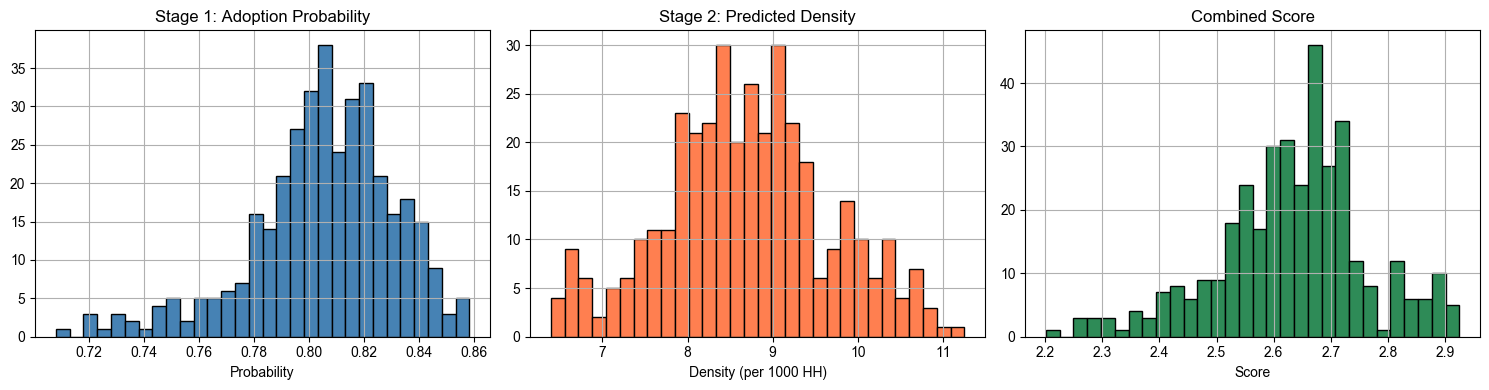

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

results['stage1_prob'].hist(bins=30, ax=axes[0], edgecolor='k', color='steelblue')
axes[0].set_title('Stage 1: Adoption Probability')
axes[0].set_xlabel('Probability')

results['stage2_density_pred'].hist(bins=30, ax=axes[1], edgecolor='k', color='coral')
axes[1].set_title('Stage 2: Predicted Density')
axes[1].set_xlabel('Density (per 1000 HH)')

results['combined_score'].hist(bins=30, ax=axes[2], edgecolor='k', color='seagreen')
axes[2].set_title('Combined Score')
axes[2].set_xlabel('Score')

plt.tight_layout()
fig_path = ROOT / 'outputs/figures/transfer/04_taiwan_prediction_distribution.png'
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f'Figure saved to {fig_path}')
plt.show()

---

## 後續建議

1. **補齊特徵**：目前僅部分特徵可直接對應。若整理住宅（房價、自有率）、政策（FIT 躉購費率）、社經（教育、失業率）資料，推論品質會進一步提升。
2. **MADA 排序**：用 `combined_score` + 日照 + 電價 + 收入做 TOPSIS，產出 `taiwan_priority_ranking.csv`。
3. **地圖視覺化**：使用 `data/taiwan/直轄市、縣(市)界線1140318/` 的 shapefile 畫 choropleth。
4. **外部驗證**：以台電或經濟部能源局的實際太陽光電裝設量計算 Spearman 相關，驗證排名合理性。